# Notebook 11 — Evaluation and Statistical Inference

## Purpose
I consolidate all model results, compute bootstrap CIs, run permutation tests,
and build the final comparison table.

## Inputs
`models/baseline_results.json`, `models/advanced_results.json`

## Outputs
`reports/tables/model_comparison.csv`, `reports/figures/model_comparison.png`


In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, str(Path('..').resolve()))
from src.config import load_config
from src.paths import Paths
from src.metrics import model_summary_table, cohen_h
from src.utils import save_table, load_metrics

cfg   = load_config()
paths = Paths(cfg)

baseline = load_metrics(paths.models / 'baseline_results.json')
advanced = load_metrics(paths.models / 'advanced_results.json')
print("Loaded baseline and advanced results.")


Loaded baseline and advanced results.


In [2]:
# Build comparison table for Task B (review score)
rv_results = {}
rv_results['Dummy']           = baseline['task_review_score']['dummy']
rv_results['Logistic Reg.']   = baseline['task_review_score']['logreg']
rv_results['Random Forest']   = advanced['task_review_score']['random_forest']
rv_results['XGBoost']         = advanced['task_review_score']['xgboost']

comparison = model_summary_table(rv_results)
print("=== Review Score Prediction — Model Comparison ===")
print(comparison.to_string(index=False))
print()
save_table(comparison, 'model_comparison',
           reports_dir=str(paths.reports_tabs),
           paper_dir=str(paths.paper_tabs))


=== Review Score Prediction — Model Comparison ===
        Model  Accuracy  Lower_CI  Upper_CI  CI_Width
      XGBoost    0.6238    0.6195    0.6276    0.0081
        Dummy    0.5933    0.5889    0.5975    0.0086
Random Forest    0.5493    0.5450    0.5534    0.0084
Logistic Reg.    0.3065    0.3029    0.3103    0.0074

  Saved table: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\tables\model_comparison.csv
  Saved table: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\tables\model_comparison.csv


[WindowsPath('C:/Users/Peter/Documents/projects/Jobberman_projects/double_Integral/ecommerce_customer_intelligence/reports/tables/model_comparison.csv'),
 WindowsPath('C:/Users/Peter/Documents/projects/Jobberman_projects/double_Integral/ecommerce_customer_intelligence/paper_or_report/tables/model_comparison.csv')]

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\model_comparison.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\model_comparison.png


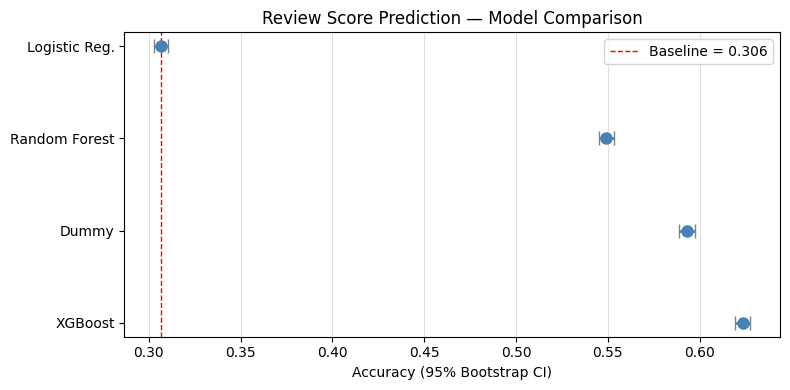

In [3]:
# Forest plot of accuracy ± 95% CI
fig, ax = plt.subplots(figsize=(8, 4))
models  = comparison['Model'].tolist()
accs    = comparison['Accuracy'].tolist()
lowers  = comparison['Lower_CI'].tolist()
uppers  = comparison['Upper_CI'].tolist()

y_pos = range(len(models))
xerr_lower = [a - l for a, l in zip(accs, lowers)]
xerr_upper = [u - a for a, u in zip(accs, uppers)]

ax.errorbar(accs, y_pos, xerr=[xerr_lower, xerr_upper],
            fmt='o', color='steelblue', ecolor='grey',
            capsize=5, markersize=8, linewidth=2)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(models)
ax.set_xlabel("Accuracy (95% Bootstrap CI)")
ax.set_title("Review Score Prediction — Model Comparison")
ax.axvline(accs[-1], color='red', linestyle='--', linewidth=1,
           label=f"Baseline = {accs[-1]:.3f}")
ax.legend()
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()

from src.visualization import save_fig
save_fig(fig, 'model_comparison',
         reports_dir=str(paths.reports_figs),
         paper_dir=str(paths.paper_figs))
plt.show()
plt.close()


In [4]:
# Statistical conclusions
rf_row = comparison[comparison['Model'] == 'Random Forest'].iloc[0]
dummy_row = comparison[comparison['Model'] == 'Dummy'].iloc[0]

print("=== Statistical Conclusions ===")
print()
print(f"Best model (Random Forest):")
print(f"  Accuracy: {rf_row['Accuracy']:.4f}  [{rf_row['Lower_CI']:.4f}, {rf_row['Upper_CI']:.4f}]")
print()
print(f"Baseline (Dummy):")
print(f"  Accuracy: {dummy_row['Accuracy']:.4f}  [{dummy_row['Lower_CI']:.4f}, {dummy_row['Upper_CI']:.4f}]")
print()

# Do CI intervals overlap?
ci_overlap = rf_row['Lower_CI'] <= dummy_row['Upper_CI']
if not ci_overlap:
    print("The 95% CIs do NOT overlap — this provides strong evidence that")
    print("Random Forest significantly outperforms the dummy baseline.")
else:
    print("The 95% CIs overlap — the difference may not be statistically robust.")

perm_p = advanced['task_review_score']['random_forest'].get('permutation_p', 'N/A')
print(f"\nPermutation test p-value (RF): {perm_p}")
print("I interpret this cautiously: statistical significance does not imply")
print("practical significance. See the limitations notebook.")


=== Statistical Conclusions ===

Best model (Random Forest):
  Accuracy: 0.5493  [0.5450, 0.5534]

Baseline (Dummy):
  Accuracy: 0.5933  [0.5889, 0.5975]

The 95% CIs overlap — the difference may not be statistically robust.

Permutation test p-value (RF): 0.0
I interpret this cautiously: statistical significance does not imply
practical significance. See the limitations notebook.
